In [1]:
import pandas as pd
import pypsa

from pathlib import Path

In [2]:
data_dir = "data"

### Load pre-compiled data

Dynamic components:

In [3]:
loads_p_set_t_df = pd.read_csv(
    Path(data_dir, "loads_p_set_t_df.csv"),
    index_col=0,
    parse_dates=True,
)

generators_p_max_pu_t_df = pd.read_csv(
    Path(data_dir, "generators_p_max_pu_t_df.csv"),
    index_col=0,
    parse_dates=True,
)

storage_units_inflow_t_df = pd.read_csv(
    Path(data_dir, "storage_units_inflow_t_df.csv"),
    index_col=0,
    parse_dates=True,
)

Static components:

In [4]:
buses_df = pd.read_csv(
    Path(data_dir, "buses_df.csv"),
    index_col=0,
)

generators_df = pd.read_csv(
    Path(data_dir, "generators_df.csv"),
    index_col=0,
)

loads_df = pd.read_csv(
    Path(data_dir, "loads_df.csv"),
    index_col=0,
)

storage_units_df = pd.read_csv(
    Path(data_dir, "storage_units_df.csv"),
    index_col=0,
)

lines_df = pd.read_csv(
    Path(data_dir, "lines_df.csv"),
    index_col=0,
)

line_types_df = pd.read_csv(
    Path(data_dir, "line_types_df.csv"),
    index_col=0,
)

### Build network

In [5]:
n = pypsa.Network()

Set a temporal dimension:

In [6]:
n.set_snapshots(loads_p_set_t_df.index)

Set carriers:

In [7]:
n.madd(
    "Carrier",
    ["hydro", "coal", "solar", "AC"],
    color=["#4DA3FF", "#4A4A4A", "#E6A817", "#888888"],
    nice_name=["Hydro", "Coal", "Solar", "AC"],
    co2_emissions=[0.025, 0.830, 0.048, 0.0],
)

Index(['hydro', 'coal', 'solar', 'AC'], dtype='object')

In [8]:
n.carriers

,color,nice_name,co2_emissions,max_growth,max_relative_growth
Carrier,,,,,
hydro,#4DA3FF,Hydro,0.025,inf,0.0
coal,#4A4A4A,Coal,0.830,inf,0.0
solar,#E6A817,Solar,0.048,inf,0.0
AC,#888888,AC,0.000,inf,0.0


In [9]:
buses_df["carrier"] = "AC"
lines_df["carrier"] = "AC"

In [10]:
n.import_components_from_dataframe(
    buses_df,
    "Bus",
)

n.import_components_from_dataframe(
    generators_df,
    "Generator",
)

n.import_components_from_dataframe(
    loads_df,
    "Load",
)

n.import_components_from_dataframe(
    storage_units_df,
    "StorageUnit",
)

n.import_components_from_dataframe(
    line_types_df,
    "LineType",
)

n.import_components_from_dataframe(
    lines_df,
    "Line",
)

In [11]:
n.buses

,v_nom,tag_substation,tag_area,lon,lat,country,x,y,control,generator,carrier,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,type,unit,sub_network
Bus,,,,,,,,,,,,,,,,,
ZM0 0,330.0,transmission,0.0,28.514364,-13.512545,ZM,28.514364,-13.512545,Slack,ZM0 0 coal,AC,1.0,0.0,inf,,,
ZM0 1,330.0,transmission,0.0,27.626734,-15.940900,ZM,27.626734,-15.940900,PQ,,AC,1.0,0.0,inf,,,
ZM0 2,330.0,transmission,0.0,31.071350,-12.563810,ZM,31.071350,-12.563810,PQ,,AC,1.0,0.0,inf,,,
ZM0 3,330.0,transmission,0.0,25.855833,-12.213800,ZM,25.855833,-12.213800,PQ,,AC,1.0,0.0,inf,,,


In [12]:
n.lines

,num_parallel,v_nom,bus0,bus1,length,dc,geometry,carrier,country,type,...,build_year,lifetime,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu
Line,,,,,,,,,,,,,,,,,,,,,
0,3.254583,330.0,ZM0 0,ZM0 1,28639.423721,False,MULTILINESTRING ((28.438601099999868 -14.45896...,AC,ZM,ZM_330kV_bison_2bundle,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
1,2.000000,330.0,ZM0 0,ZM0 2,29639.857050,False,"MULTILINESTRING ((28.5722 -14.5945, 28.5728081...",AC,ZM,ZM_330kV_bison_2bundle,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
2,1.000000,330.0,ZM0 0,ZM0 3,32234.721971,False,MULTILINESTRING ((27.981223099999912 -12.60364...,AC,ZM,ZM_330kV_bison_2bundle,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
3,2.000000,330.0,ZM0 1,ZM0 3,45631.365916,False,MULTILINESTRING ((25.294883199999965 -12.29139...,AC,ZM,ZM_330kV_bison_2bundle,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0


In [13]:
n.storage_units

,carrier,bus,p_nom,max_hours,marginal_cost,p_min_pu,efficiency_dispatch,efficiency_store,cyclic_state_of_charge,control,...,marginal_cost_storage,capital_cost,build_year,lifetime,state_of_charge_initial,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge_per_period,standing_loss,inflow
StorageUnit,,,,,,,,,,,,,,,,,,,,,
ZM0 0 hydro,hydro,ZM0 0,24.0,392.700000,1.059920,0.0,0.9,0.0,True,,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0
ZM0 1 hydro,hydro,ZM0 1,2972.0,4223.672207,1.060793,0.0,0.9,0.0,True,,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0
ZM0 2 hydro,hydro,ZM0 2,37.0,6.000000,1.059380,0.0,0.9,0.0,True,,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0


In [14]:
n.generators

,carrier,bus,p_nom,p_nom_min,p_nom_max,efficiency,marginal_cost,capital_cost,build_year,lifetime,...,shut_down_cost,stand_by_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Generator,,,,,,,,,,,,,,,,,,,,,
ZM0 0 coal,coal,ZM0 0,30.0,30.0,30.000000,0.356,4.009920,71141.962001,2015,45.0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
ZM0 0 solar,solar,ZM0 0,34.0,34.0,85573.796911,1.000,0.009412,71739.288452,0,25.0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
ZM0 1 coal,coal,ZM0 1,300.0,300.0,300.000000,0.356,4.009139,71141.962001,2016,45.0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
ZM0 1 solar,solar,ZM0 1,88.0,88.0,264649.505131,1.000,0.009102,71739.288452,0,25.0,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0


~/miniforge3/envs/pypsa-earth-aug/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x179c0c6d0>,
 <matplotlib.collections.LineCollection at 0x177ef6950>)

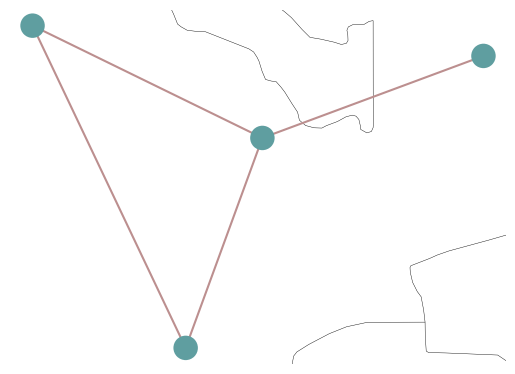

In [15]:
n.plot()

#### Import dynamic components

In [16]:
n.import_series_from_dataframe(
    loads_p_set_t_df,
    "Load",
    "p_set",
)

n.import_series_from_dataframe(
    generators_p_max_pu_t_df,
    "Generator",
    "p_max_pu",
)

n.import_series_from_dataframe(
    storage_units_inflow_t_df,
    "StorageUnit",
    "inflow",
)

In [17]:
n.loads_t["p_set"].sum()

Load
ZM0 0    48835.679436
ZM0 1    10512.493981
ZM0 2     7098.845478
ZM0 3    12099.696608
dtype: float64

Add load shedding to avoid infeasibilities:

In [18]:
n.add(
    "Carrier",
    "shedding",
    color="#E57373",
    nice_name="Load shedding",
)

n.madd(
    "Generator",
    names=n.buses.index + " LoadShedding",
    bus=n.buses.index,
    carrier="shedding",
    capital_cost=0,
    marginal_cost=100_000,
    p_nom_extendable=True,
)

Index(['ZM0 0 LoadShedding', 'ZM0 1 LoadShedding', 'ZM0 2 LoadShedding',
       'ZM0 3 LoadShedding'],
      dtype='object', name='Bus')

#### Solving

In [19]:
n.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.04s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1156 primals, 2404 duals
Objective: 1.07e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-35t4j59w has 2404 rows; 1156 cols; 3988 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+04]
  Cost   [9e-03, 1e+05]
  Bound  [4e-01, 1e+03]
  RHS    [4e-01, 1e+07]
Presolving model
384 rows, 959 cols, 1583 nonzeros  0s
Dependent equations search running on 384 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
384 rows, 959 cols, 1583 nonzeros  0s
Presolve : Reductions: rows 384(-2020); columns 959(-197); elements 1583(-2405)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.2398923122e+01 Pr: 384(2.87619e+08) 0s
        456     1.0684787097e+09 Pr: 0(0); Du: 0(1.77636e-15) 0s
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-35t4j59w
Model status        : Optimal
Simplex   it

('ok', 'optimal')

In [20]:
n.statistics()

Optimal Capacity  Installed Capacity       Supply  \
Generator   Coal                  330.00000           330.00000  15840.00000   
            Load shedding        5413.60382             0.00000  10683.60543   
            Solar                 122.00000           122.00000    499.31067   
Line        AC                   7549.00488          7549.00488  74979.36588   
Load        -                       0.00000             0.00000      0.00000   
StorageUnit Hydro                3033.00000          3033.00000  51523.79941   

                            Withdrawal  Energy Balance  Transmission  \
Generator   Coal               0.00000     15840.00000       0.00000   
            Load shedding      0.00000     10683.60543       0.00000   
            Solar              0.00000       499.31067       0.00000   
Line        AC             74979.36588         0.00000  -32486.44501   
Load        -              78546.71550    -78546.71550       0.00000   
StorageUnit Hydro              0.00000     51523.79941       0.00000   

                           Capacity Factor   Curtailment  Capital Expenditure  \
Generator   Coal                  1.000000       0.00000         2.347685e+07   
            Load shedding         0.041114  249169.37813         0.000000e+00   
            Solar                 0.085265       0.00000         8.752193e+06   
Line        AC                    0.206924       0.00000         1.062779e+10   
Load        -                          NaN       0.00000         0.000000e+00   
StorageUnit Hydro                 0.353911   94060.20059         0.000000e+00   

                           Operational Expenditure       Revenue  \
Generator   Coal                      6.350588e+04  1.584000e+09   
            Load shedding             1.068361e+09  1.068361e+09   
            Solar                     4.596790e+00  4.993107e+07   
Line        AC                        0.000000e+00  0.000000e+00   
Load        -                         0.000000e+00 -7.854672e+09   
StorageUnit Hydro                     5.465596e+04  5.152380e+09   

                            Market Value  
Generator   Coal           100000.000000  
            Load shedding  100000.001427  
            Solar           99999.956953  
Line        AC                       NaN  
Load        -                        NaN  
StorageUnit Hydro           99999.999778

In [21]:
n.generators_t["p"].sum()

Generator
ZM0 0 coal             1440.000000
ZM0 0 solar             167.430612
ZM0 1 coal            14400.000000
ZM0 1 solar             331.880053
ZM0 0 LoadShedding     1246.844889
ZM0 1 LoadShedding     3139.993531
ZM0 2 LoadShedding     4841.514207
ZM0 3 LoadShedding     1455.252806
dtype: float64